In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

X,y = make_classification(
    n_features=5, 
    n_redundant=0,
    n_informative=5,
    n_clusters_per_class=1,
    random_state=42
)

df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y 

df.head()
df.shape

(100, 6)

In [12]:
def sample_rows(df, percent):
    num_rows = int(percent * df.shape[0])
    return df.sample(num_rows, replace=True)


In [13]:
def sample_features(df, percent):
    all_features = df.columns.tolist()[:-1]
    num_features = int(percent * len(all_features))

    selected_cols = random.sample(all_features, num_features)

    new_df = df[selected_cols].copy()
    new_df['target'] = df['target']
    return new_df

In [14]:
def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_features(new_df, col_percent)


In [15]:
df1 = combined_sampling(df, 0.5, 0.5)
df2 = combined_sampling(df, 0.5, 0.5)
df3 = combined_sampling(df, 0.5, 0.5)

print("features for tree 1 :", df1.columns.tolist())
print("features for tree 2 :", df2.columns.tolist())
print("features for tree 3 :", df2.columns.tolist())

features for tree 1 : ['col2', 'col1', 'target']
features for tree 2 : ['col3', 'col4', 'target']
features for tree 3 : ['col3', 'col4', 'target']


In [16]:
from sklearn.tree import DecisionTreeClassifier

clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

clf1.fit(df1.iloc[:, :-1], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, :-1], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, :-1], df3.iloc[:, -1])


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

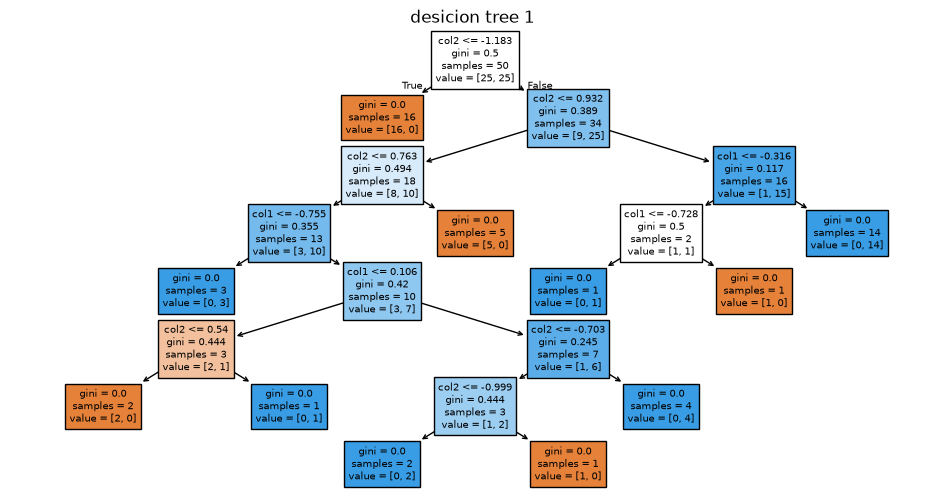

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(clf1, filled=True, feature_names=df1.columns[:-1])
plt.title("desicion tree 1 ")
plt.show()

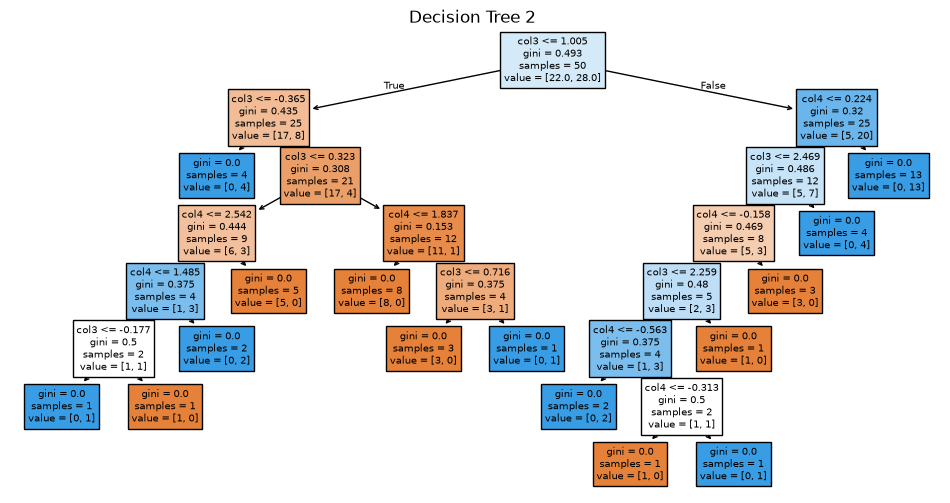

In [19]:
plt.figure(figsize=(12, 6))
plot_tree(clf2, filled=True, feature_names=df2.columns[:-1])
plt.title("Decision Tree 2 ")
plt.show()

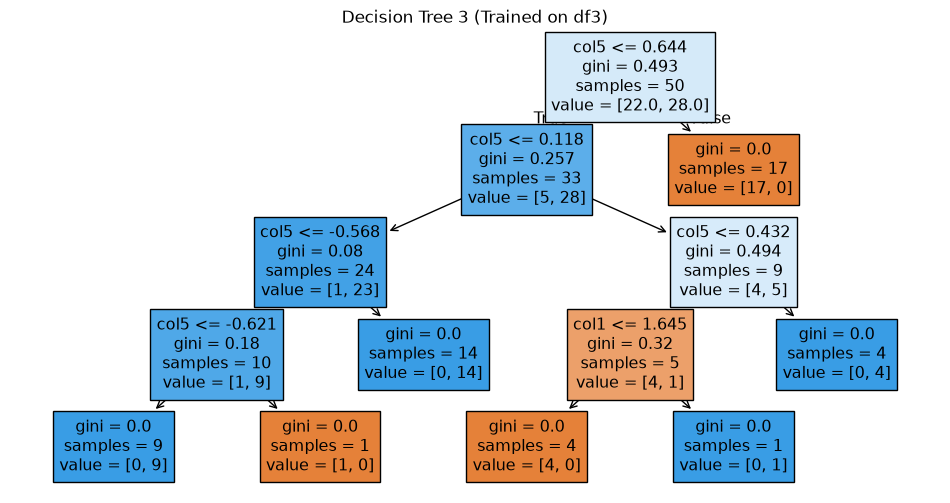

In [20]:
plt.figure(figsize=(12, 6))
plot_tree(clf3, filled=True, feature_names=df3.columns[:-1])
plt.title("Decision Tree 3 (Trained on df3)")
plt.show()

In [22]:
test_point = df.iloc[0:1, :-1]
actual_answer = df.iloc[0]['target']

test_point

,col1,col2,col3,col4,col5
0,1.053909,-3.861208,1.530963,0.596692,1.030284


In [24]:
# Tree 1
features_for_tree1 = df1.columns[:-1]
pred1 = clf1.predict(test_point[features_for_tree1])[0]
# Tree 2
features_for_tree2 = df2.columns[:-1]
pred2 = clf2.predict(test_point[features_for_tree2])[0]
# Tree 3
features_for_tree3 = df3.columns[:-1]
pred3 = clf3.predict(test_point[features_for_tree3])[0]

In [25]:
print(f"\nTree 1 Predicted: Class {pred1}")
print(f"Tree 2 Predicted: Class {pred2}")
print(f"Tree 3 Predicted: Class {pred3}")


Tree 1 Predicted: Class 0
Tree 2 Predicted: Class 1
Tree 3 Predicted: Class 0


In [26]:
predictions = [pred1, pred2, pred3]
final_vote = max(set(predictions), key=predictions.count)

In [27]:
print(f"Majority Vote Result : Class {final_vote}")
print(f"Actual/Real Answer   : Class {actual_answer}")

Majority Vote Result : Class 0
Actual/Real Answer   : Class 0.0
